# ISIMIP Implementation Check

Markdown added by Claude based on interview, code written manually. This notebook verified that calling `ibicus.debias.ISIMIP` directly, with the same inputs and settings as the production `srm` pipeline, reproduces the pipeline's own debiased-coarse output at a single point.

**Config under test:** `configs/qa/cesm2-waccm/cesm2-waccm-ssp245-std-southafrica.yaml`
- GCM: CESM2-WACCM, ensemble member 003 (`r3i1p1f1` in the historical catalog)
- Variable: `pr`
- Scenario: SSP245
- Training period: 1978-2014
- Point: Cape Town, South Africa (lat -33.99, lon 18.55)

In [23]:
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from ibicus.debias import ISIMIP, QuantileDeltaMapping

from srm import catalog

# Get data

Load the three data sources needed for the point-level comparison: the raw GCM inputs, the pipeline's cached regridded-to-coarse ERA5 observations, and the pipeline's own debiased-coarse output.

### Input data

Load the raw GCM historical and SSP245 `pr` data from the catalog for ensemble member 003 (`r3i1p1f1` in the historical naming). The historical record is clipped to the training period (1978-2014) to match `train_period_start`/`train_period_end` in the config; the SSP245 record already covers exactly the predict period (2015-2099), so no clipping is needed there. Then extract the single point from each.

In [2]:
pt_lat = -33.98668063995415
pt_lon = 18.551467673255665
train_slice = slice("1978-01-01", "2014-12-31")

In [3]:
gcm_fut_global = catalog.get("CESM2-WACCM").to_xarray()["ssp245"]["pr"].sel(ensemble_member="003")
gcm_hist_global = (
    catalog.get("CESM2-WACCM").to_xarray()["historical"]["pr"].sel(ensemble_member="r3i1p1f1")
)
gcm_hist_global = gcm_hist_global.sel(time=train_slice)

In [4]:
gcm_fut_pt = gcm_fut_global.sel(lat=[pt_lat], lon=[pt_lon], method="nearest")
gcm_hist_pt = gcm_hist_global.sel(lat=[pt_lat], lon=[pt_lon], method="nearest")

### Cached regridded obs

Open the icechunk cache store the pipeline writes to during the `obs_regridded` stage, and load ERA5 `pr` regridded onto the GCM's coarse grid (group `obs/pr`). This cache is shared across configs and spans the full available ERA5 record, so it's clipped to the same training period (1978-2014) before extracting the point.

In [5]:
cache_storage = icechunk.s3_storage(
    bucket="carbonplan-scratch",
    prefix="srm-isimip/cache/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk",
    region="us-west-2",
)
cache_repo = icechunk.Repository.open(cache_storage)
cache_session = cache_repo.readonly_session(branch="isimip-test")

obs_coarse = xr.open_zarr(cache_session.store, group="obs/pr", consolidated=False)["pr"]
obs_coarse = obs_coarse.sel(time=train_slice)

In [6]:
obs_coarse_pt = obs_coarse.sel(lat=[pt_lat], lon=[pt_lon], method="nearest")

In [84]:
cache_storage = icechunk.s3_storage(
    bucket="carbonplan-scratch",
    prefix="srm-qdm/cache/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk",
    region="us-west-2",
)
cache_repo = icechunk.Repository.open(cache_storage)
cache_session = cache_repo.readonly_session(branch="qdm-test2")

obs_coarse = xr.open_zarr(cache_session.store, group="obs/pr", consolidated=False)["pr"]
obs_coarse = obs_coarse.sel(time=train_slice)

### Output data

Open the icechunk output store and load the pipeline's own debiased-coarse `pr` for the historical and SSP245 periods (groups `debiased_coarse/historical/pr/r3i1p1f1` and `debiased_coarse/ssp245/pr/003`) — this is the production result being checked against. Extract the same point.

In [7]:
storage = icechunk.s3_storage(
    bucket="carbonplan-scratch",
    prefix="srm-isimip/output/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk",
    region="us-west-2",
)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session(branch="isimip-test")

In [8]:
output_fut_isimip = xr.open_zarr(
    session.store, group="debiased_coarse/ssp245/pr/003", consolidated=False
)["pr"]
output_hist_isimip = xr.open_zarr(
    session.store, group="debiased_coarse/historical/pr/r3i1p1f1", consolidated=False
)["pr"]

In [10]:
output_fut_isimip_pt = output_fut_isimip.sel(lat=[pt_lat], lon=[pt_lon], method="nearest")
output_hist_isimip_pt = output_hist_isimip.sel(lat=[pt_lat], lon=[pt_lon], method="nearest")

In [11]:
storage = icechunk.s3_storage(
    bucket="carbonplan-scratch",
    prefix="srm-qdm/output/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk",
    region="us-west-2",
)
repo = icechunk.Repository.open(storage)
session = repo.readonly_session(branch="qdm-test2")

In [12]:
output_fut_qdm = xr.open_zarr(
    session.store, group="debiased_coarse/ssp245/pr/003", consolidated=False
)["pr"]
output_hist_qdm = xr.open_zarr(
    session.store, group="debiased_coarse/historical/pr/r3i1p1f1", consolidated=False
)["pr"]

In [13]:
output_fut_qdm_pt = output_fut_qdm.sel(lat=[pt_lat], lon=[pt_lon], method="nearest")
output_hist_qdm_pt = output_hist_qdm.sel(lat=[pt_lat], lon=[pt_lon], method="nearest")

# Run bias correction at point scale

## Run ISIMIP

Instantiate `ibicus.debias.ISIMIP` for `pr` using its per-variable defaults. Apply it directly to the point-level obs/cm_hist/cm_future arrays, passing the real `time_obs`/`time_cm_hist`/`time_cm_future` coordinates so ISIMIP's running-window/day-of-year logic uses the actual calendar dates (note: this is an important step! if we don't do this, it gives a different answer. I don't understand why that is, maybe something leap year related)

In [14]:
debiaser_isimip = ISIMIP.from_variable(variable="pr")

In [15]:
debiased_cm_future_isimip = debiaser_isimip.apply(
    obs=obs_coarse_pt.values,
    cm_hist=gcm_hist_pt.values,
    cm_future=gcm_fut_pt.values,
    time_obs=obs_coarse_pt["time"].values,
    time_cm_hist=gcm_hist_pt["time"].values,
    time_cm_future=gcm_fut_pt["time"].values,
)

100%|██████████| 1/1 [00:04<00:00,  4.20s/it]


In [16]:
debiased_cm_future_isimip_time1 = debiaser_isimip.apply(
    obs=obs_coarse_pt.values,
    cm_hist=gcm_hist_pt.values,
    cm_future=gcm_fut_pt.sel(time=slice("2015-01-01", "2045-12-31")).values,
    time_obs=obs_coarse_pt["time"].values,
    time_cm_hist=gcm_hist_pt["time"].values,
    time_cm_future=gcm_fut_pt["time"].sel(time=slice("2015-01-01", "2045-12-31")).values,
)

100%|██████████| 1/1 [00:02<00:00,  2.10s/it]


In [17]:
debiased_cm_future_isimip_time2 = debiaser_isimip.apply(
    obs=obs_coarse_pt.values,
    cm_hist=gcm_hist_pt.values,
    cm_future=gcm_fut_pt.sel(time=slice("2070-01-01", "2099-12-31")).values,
    time_obs=obs_coarse_pt["time"].values,
    time_cm_hist=gcm_hist_pt["time"].values,
    time_cm_future=gcm_fut_pt["time"].sel(time=slice("2070-01-01", "2099-12-31")).values,
)

100%|██████████| 1/1 [00:02<00:00,  2.10s/it]


## Run QDM

In [157]:
debiaser_qdm = QuantileDeltaMapping.from_variable(
    variable="pr",
    running_window_length=31,
    mapping_type="nonparametric",
    trend_preservation="relative",
    censor_values_to_zero=True,
    censoring_threshold=0.05 / 86400,
    running_window_step_length=1,
)

In [168]:
np.random.seed(10)
debiased_cm_future_qdm = debiaser_qdm.apply(
    obs=obs_coarse_pt.values,
    cm_hist=gcm_hist_pt.values,
    cm_future=gcm_fut_pt.values,
    time_obs=obs_coarse_pt["time"].values,
    time_cm_hist=gcm_hist_pt["time"].values,
    time_cm_future=gcm_fut_pt["time"].values,
)

100%|██████████| 1/1 [00:56<00:00, 56.54s/it]


In [133]:
debiased_cm_future_qdm_time1 = debiaser_qdm.apply(
    obs=obs_coarse_pt.values,
    cm_hist=gcm_hist_pt.values,
    cm_future=gcm_fut_pt.sel(time=slice("2015-01-01", "2045-12-31")).values,
    time_obs=obs_coarse_pt["time"].values,
    time_cm_hist=gcm_hist_pt["time"].values,
    time_cm_future=gcm_fut_pt["time"].sel(time=slice("2015-01-01", "2065-12-31")).values,
)

100%|██████████| 1/1 [00:14<00:00, 14.71s/it]


In [134]:
debiased_cm_future_qdm_time2 = debiaser_qdm.apply(
    obs=obs_coarse_pt.values,
    cm_hist=gcm_hist_pt.values,
    cm_future=gcm_fut_pt.sel(time=slice("2070-01-01", "2099-12-31")).values,
    time_obs=obs_coarse_pt["time"].values,
    time_cm_hist=gcm_hist_pt["time"].values,
    time_cm_future=gcm_fut_pt["time"].sel(time=slice("2050-01-01", "2099-12-31")).values,
)

100%|██████████| 1/1 [00:13<00:00, 13.97s/it]


# Compare Results

Compare the standalone ISIMIP call above (`debiased_cm_future_isimip`) against the pipeline's own debiased-coarse SSP245 output (`output_fut_pt`) at the same point: a 1:1 scatter plot, an overlaid time series for the first 200 days, and the residual (standalone minus pipeline) plotted by day of year.

## ISIMIP

Text(0, 0.5, 'Output of ISIMIP run')

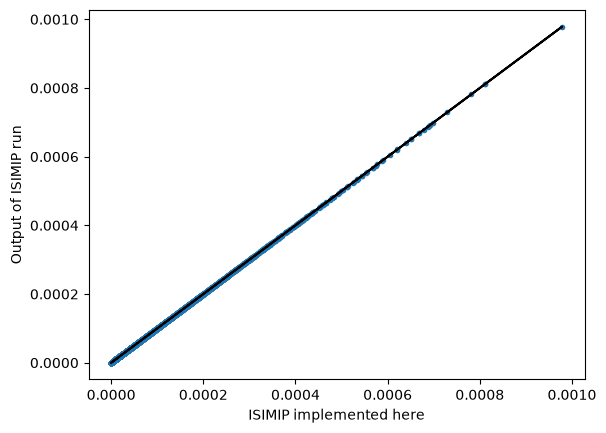

In [27]:
plt.plot(debiased_cm_future_isimip[:, 0, 0], output_fut_isimip_pt[:, 0, 0], ".")
plt.plot(debiased_cm_future_isimip[:, 0, 0], debiased_cm_future_isimip[:, 0, 0], "-k")
plt.xlabel("ISIMIP implemented here")
plt.ylabel("Output of ISIMIP run")

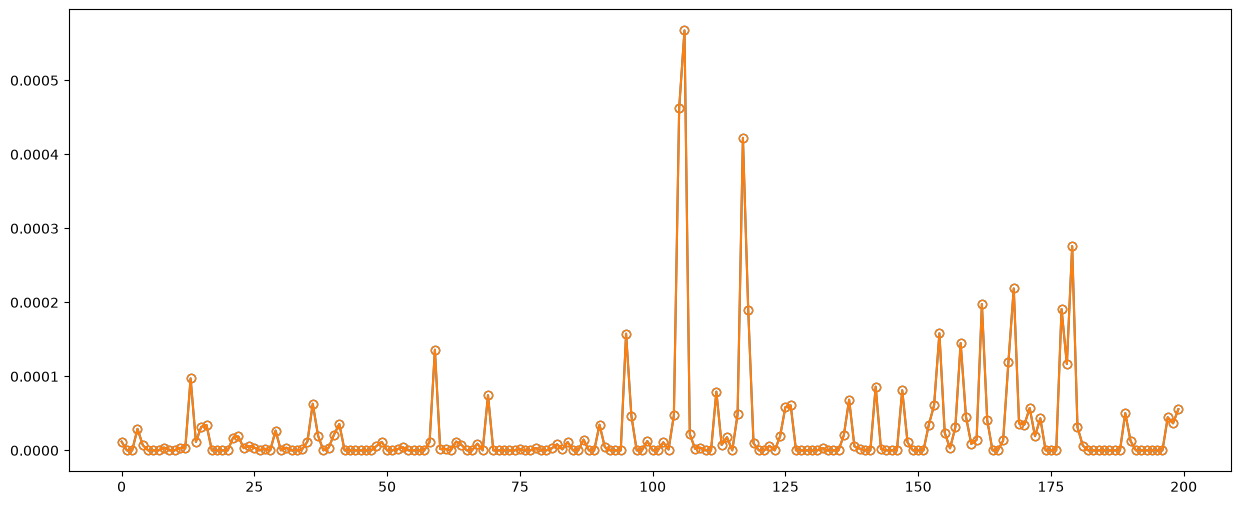

In [29]:
plt.figure(figsize=(15, 6))
plt.plot(output_fut_isimip_pt[0:200, 0, 0], marker="o", fillstyle="none")
plt.plot(debiased_cm_future_isimip[0:200, 0, 0], marker="o", fillstyle="none")

Text(0.5, 0, 'Day of year')

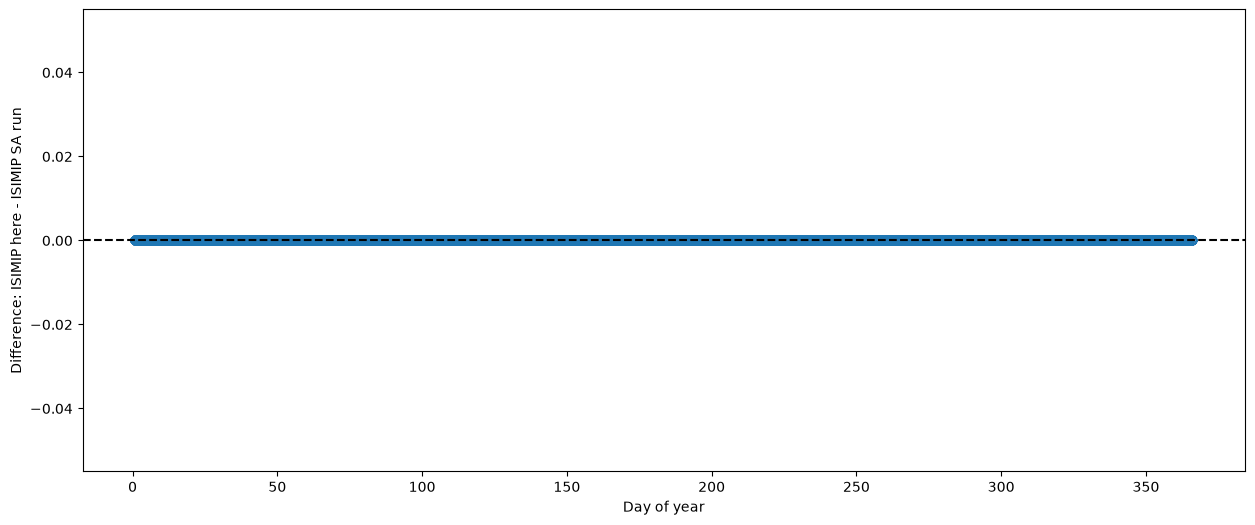

In [30]:
plt.figure(figsize=(15, 6))
plt.plot(
    output_fut_isimip_pt["time.dayofyear"],
    debiased_cm_future_isimip[:, 0, 0] - output_fut_isimip_pt[:, 0, 0],
    marker="o",
    fillstyle="none",
    linestyle="none",
)
plt.axhline(y=0, linestyle="--", color="k")
plt.ylabel("Difference: ISIMIP here - ISIMIP SA run")
plt.xlabel("Day of year")

## QDM

Text(0, 0.5, 'Output of ISIMIP run')

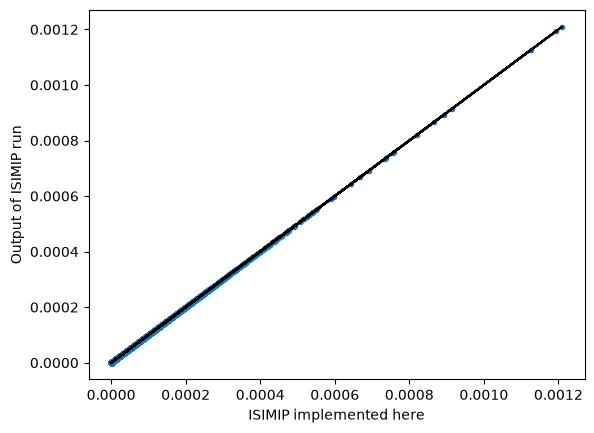

In [135]:
plt.plot(debiased_cm_future_qdm[:, 0, 0], output_fut_qdm_pt[:, 0, 0], ".")
plt.plot(debiased_cm_future_qdm[:, 0, 0], debiased_cm_future_qdm[:, 0, 0], "-k")
plt.xlabel("ISIMIP implemented here")
plt.ylabel("Output of ISIMIP run")

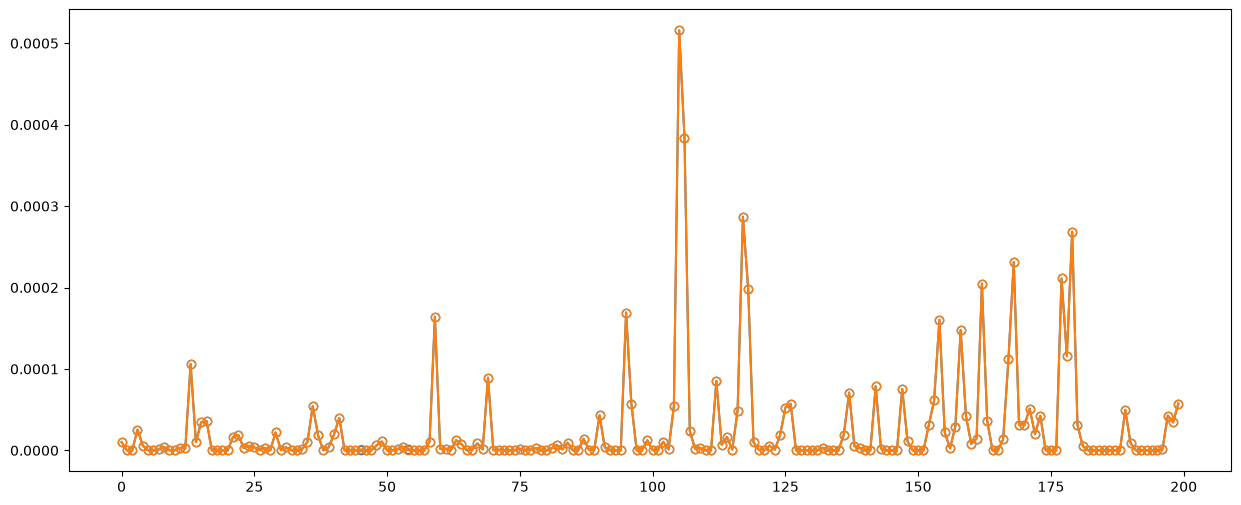

In [162]:
plt.figure(figsize=(15, 6))
plt.plot(output_fut_qdm_pt[0:200, 0, 0], marker="o", fillstyle="none")
plt.plot(debiased_cm_future_qdm[0:200, 0, 0], marker="o", fillstyle="none")

Text(0.5, 0, 'Day of year')

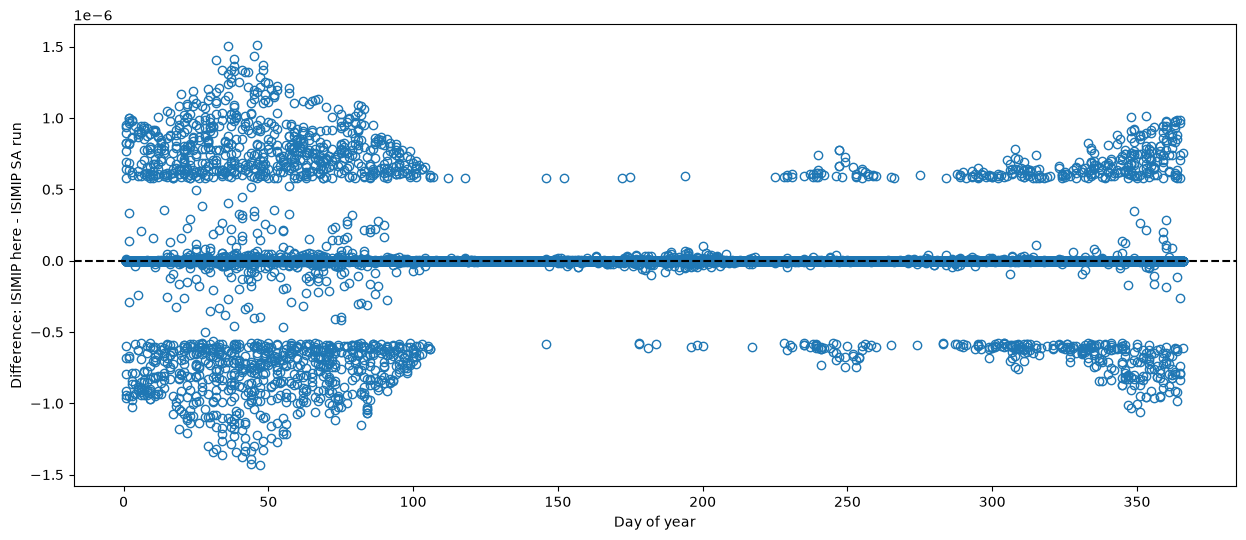

In [170]:
plt.figure(figsize=(15, 6))
plt.plot(
    output_fut_qdm_pt["time.dayofyear"],
    debiased_cm_future_qdm[:, 0, 0] - output_fut_qdm_pt[:, 0, 0],
    marker="o",
    fillstyle="none",
    linestyle="none",
)
plt.axhline(y=0, linestyle="--", color="k")
plt.ylabel("Difference: ISIMIP here - ISIMIP SA run")
plt.xlabel("Day of year")

Text(0.5, 0, 'Day of year')

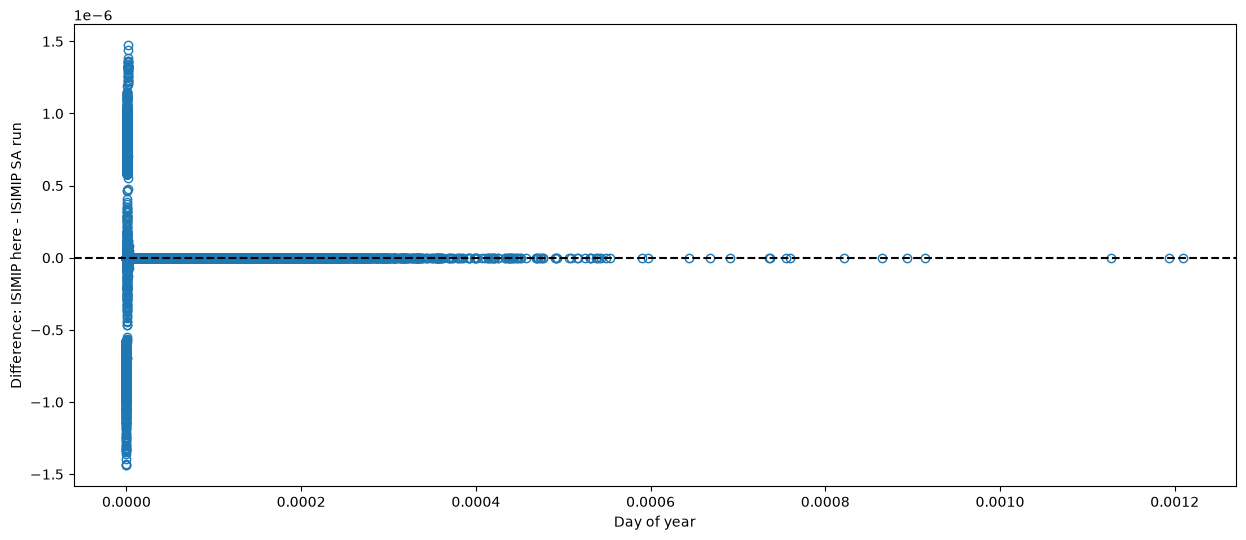

In [148]:
plt.figure(figsize=(15, 6))
plt.plot(
    debiased_cm_future_qdm[:, 0, 0],
    debiased_cm_future_qdm[:, 0, 0] - output_fut_qdm_pt[:, 0, 0],
    marker="o",
    fillstyle="none",
    linestyle="none",
)
plt.axhline(y=0, linestyle="--", color="k")
plt.ylabel("Difference: ISIMIP here - ISIMIP SA run")
plt.xlabel("Day of year")

# Does time slice change the answer?

## ISIMIP

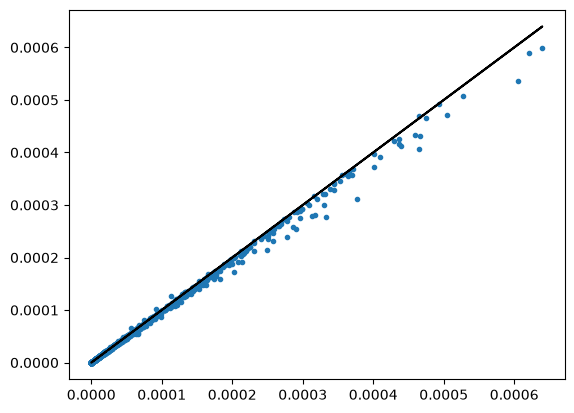

In [110]:
plt.plot(
    debiased_cm_future_isimip[20 * 365 : 31 * 365 + 8, 0, 0],
    debiased_cm_future_isimip_time1[20 * 365 :, 0, 0],
    ".",
)
plt.plot(
    debiased_cm_future_isimip[20 * 365 : 31 * 365 + 8, 0, 0],
    debiased_cm_future_isimip[20 * 365 : 31 * 365 + 8, 0, 0],
    "-k",
)

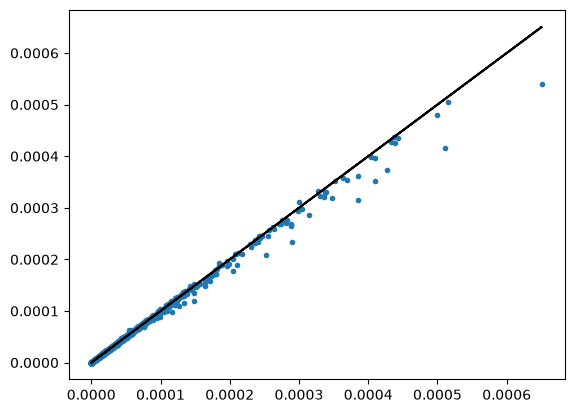

In [111]:
plt.plot(
    debiased_cm_future_isimip[365 * 75 + 14 :, 0, 0],
    debiased_cm_future_isimip_time2[365 * 20 :, 0, 0],
    ".",
)
plt.plot(
    debiased_cm_future_isimip[365 * 75 + 14 :, 0, 0],
    debiased_cm_future_isimip[365 * 75 + 14 :, 0, 0],
    "-k",
)

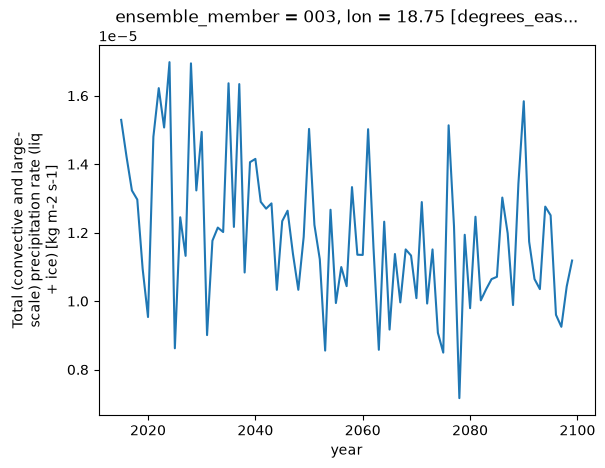

In [112]:
gcm_fut_pt.groupby("time.year").mean()[:, 0, 0].plot()

## QDM

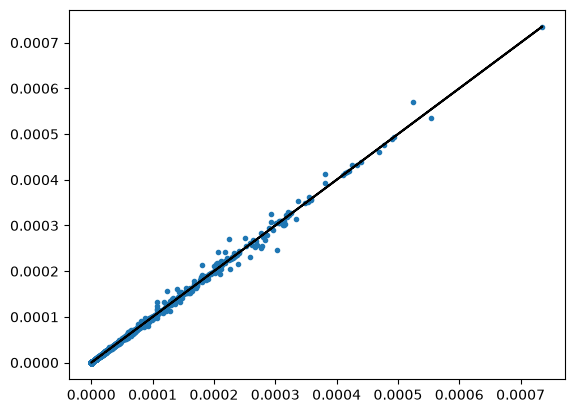

In [113]:
plt.plot(
    debiased_cm_future_qdm[20 * 365 : 31 * 365 + 8, 0, 0],
    debiased_cm_future_qdm_time1[20 * 365 :, 0, 0],
    ".",
)
plt.plot(
    debiased_cm_future_qdm[20 * 365 : 31 * 365 + 8, 0, 0],
    debiased_cm_future_qdm[20 * 365 : 31 * 365 + 8, 0, 0],
    "-k",
)

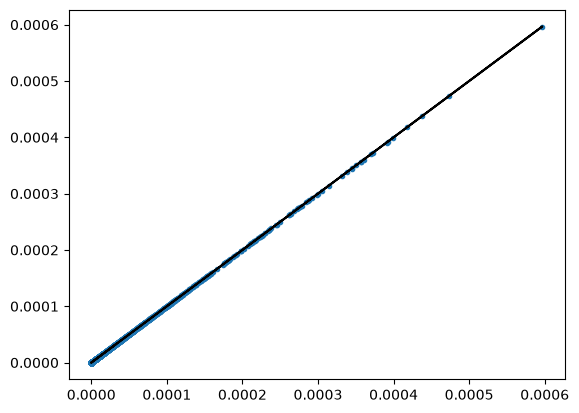

In [114]:
plt.plot(
    debiased_cm_future_qdm[365 * 75 + 14 :, 0, 0],
    debiased_cm_future_qdm_time2[365 * 20 :, 0, 0],
    ".",
)
plt.plot(
    debiased_cm_future_qdm[365 * 75 + 14 :, 0, 0],
    debiased_cm_future_qdm[365 * 75 + 14 :, 0, 0],
    "-k",
)

(np.float64(36525.0), np.float64(47482.0))

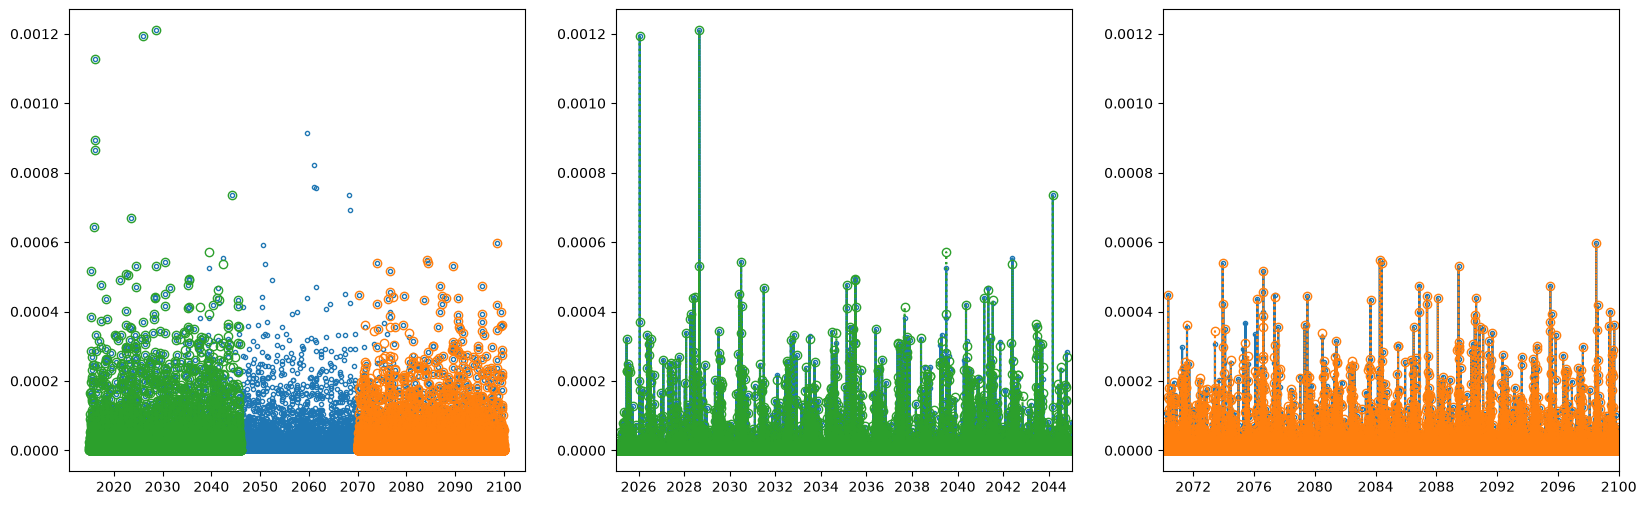

In [128]:
plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.plot(
    gcm_fut_pt["time"],
    debiased_cm_future_qdm[:, 0, 0],
    marker=".",
    fillstyle="none",
    linestyle="none",
)
plt.plot(
    gcm_fut_pt["time"][365 * 55 + 14 :],
    debiased_cm_future_qdm_time2[:, 0, 0],
    marker="o",
    fillstyle="none",
    linestyle="none",
)
plt.plot(
    gcm_fut_pt["time"][: 31 * 365 + 8],
    debiased_cm_future_qdm_time1[:, 0, 0],
    marker="o",
    fillstyle="none",
    linestyle="none",
)
plt.subplot(1, 3, 2)
plt.plot(
    gcm_fut_pt["time"], debiased_cm_future_qdm[:, 0, 0], marker=".", fillstyle="none"
)  # ,linestyle='none')
plt.plot(
    gcm_fut_pt["time"][: 31 * 365 + 8],
    debiased_cm_future_qdm_time1[:, 0, 0],
    marker="o",
    fillstyle="none",
    linestyle=":",
    color="C2",
)
plt.xlim(np.datetime64("2025-01-01"), np.datetime64("2045-01-01"))
plt.subplot(1, 3, 3)
plt.plot(
    gcm_fut_pt["time"], debiased_cm_future_qdm[:, 0, 0], marker=".", fillstyle="none"
)  # ,linestyle='none')
plt.plot(
    gcm_fut_pt["time"][365 * 55 + 14 :],
    debiased_cm_future_qdm_time2[:, 0, 0],
    marker="o",
    fillstyle="none",
    linestyle=":",
)
plt.xlim(np.datetime64("2070-01-01"), np.datetime64("2100-01-01"))

(np.float64(42369.0), np.float64(43099.0))

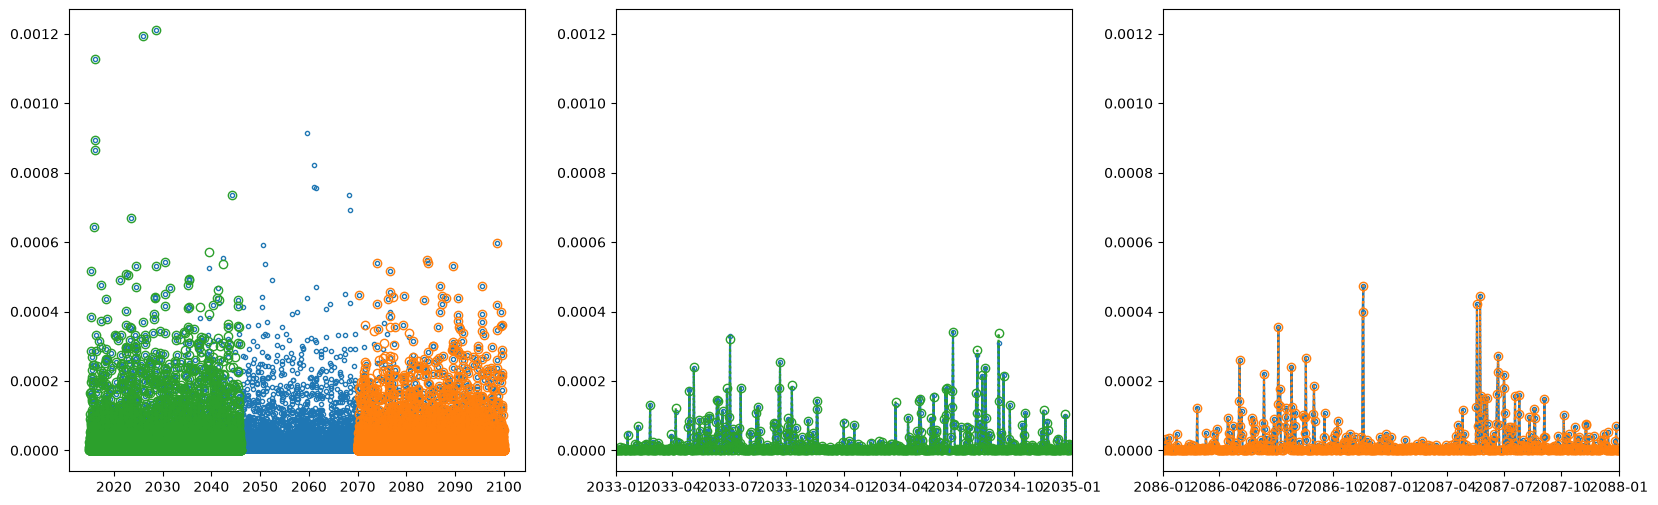

In [139]:
plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.plot(
    gcm_fut_pt["time"],
    debiased_cm_future_qdm[:, 0, 0],
    marker=".",
    fillstyle="none",
    linestyle="none",
)
plt.plot(
    gcm_fut_pt["time"][365 * 55 + 14 :],
    debiased_cm_future_qdm_time2[:, 0, 0],
    marker="o",
    fillstyle="none",
    linestyle="none",
)
plt.plot(
    gcm_fut_pt["time"][: 31 * 365 + 8],
    debiased_cm_future_qdm_time1[:, 0, 0],
    marker="o",
    fillstyle="none",
    linestyle="none",
)
plt.subplot(1, 3, 2)
plt.plot(
    gcm_fut_pt["time"], debiased_cm_future_qdm[:, 0, 0], marker=".", fillstyle="none"
)  # ,linestyle='none')
plt.plot(
    gcm_fut_pt["time"][: 31 * 365 + 8],
    debiased_cm_future_qdm_time1[:, 0, 0],
    marker="o",
    fillstyle="none",
    linestyle=":",
    color="C2",
)
plt.xlim(np.datetime64("2033-01-01"), np.datetime64("2035-01-01"))
plt.subplot(1, 3, 3)
plt.plot(
    gcm_fut_pt["time"], debiased_cm_future_qdm[:, 0, 0], marker=".", fillstyle="none"
)  # ,linestyle='none')
plt.plot(
    gcm_fut_pt["time"][365 * 55 + 14 :],
    debiased_cm_future_qdm_time2[:, 0, 0],
    marker="o",
    fillstyle="none",
    linestyle=":",
)
plt.xlim(np.datetime64("2086-01-01"), np.datetime64("2088-01-01"))

# Show effect of randomness

In [171]:
np.random.seed(10)
debiased_cm_future_qdm = debiaser_qdm.apply(
    obs=obs_coarse_pt.values,
    cm_hist=gcm_hist_pt.values,
    cm_future=gcm_fut_pt.values,
    time_obs=obs_coarse_pt["time"].values,
    time_cm_hist=gcm_hist_pt["time"].values,
    time_cm_future=gcm_fut_pt["time"].values,
)

np.random.seed(42)
debiased_cm_future_qdm_run2 = debiaser_qdm.apply(
    obs=obs_coarse_pt.values,
    cm_hist=gcm_hist_pt.values,
    cm_future=gcm_fut_pt.values,
    time_obs=obs_coarse_pt["time"].values,
    time_cm_hist=gcm_hist_pt["time"].values,
    time_cm_future=gcm_fut_pt["time"].values,
)

diff_seeded = np.asarray(debiased_cm_future_qdm[:, 0, 0]) - np.asarray(
    debiased_cm_future_qdm_run2[:, 0, 0]
)
print(f"max |diff| with matched seed before each call: {np.abs(diff_seeded).max():.3e}")

100%|██████████| 1/1 [00:56<00:00, 56.58s/it]

max |diff| with matched seed before each call: 1.582e-06


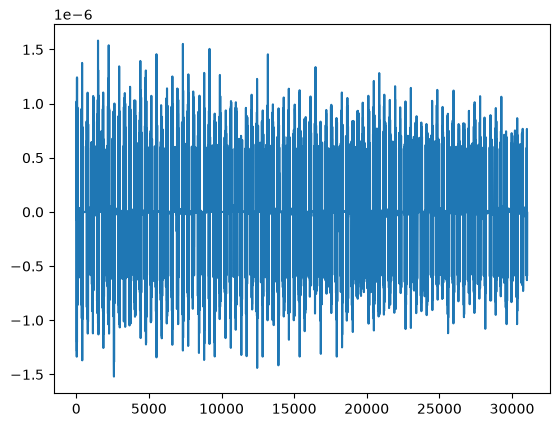

In [172]:
plt.plot(diff_seeded)

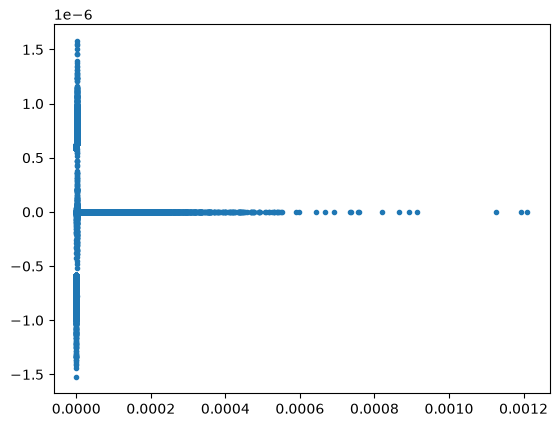

In [173]:
plt.plot(debiased_cm_future_qdm[:, 0, 0], diff_seeded, ".")